# Matplotlib

![](https://miro.medium.com/v2/resize:fit:1400/1*OAFEIg9w1XHyZk0xBud14A.png)



## Matplotlib básico

Importamos matplotlib

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

El comando básico es plot, permite generar curvas tipo funciones f(x,y) o scatter plots básicos

https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html, ver los format strings

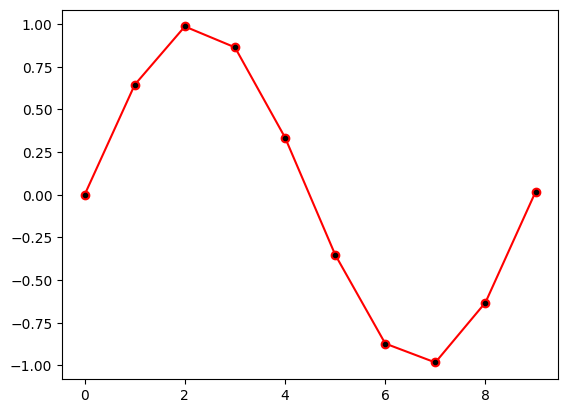

In [ ]:
x = np.arange(10)
y = np.sin(0.7*x)
plt.plot(x,y, '-ro');
plt.plot(x,y, '.k');
# con un format string como 3er argumento se puede setear el marker, color y tipo de linea;

**PREGUNTA**: Tiene algún problema el gráfico anterior?

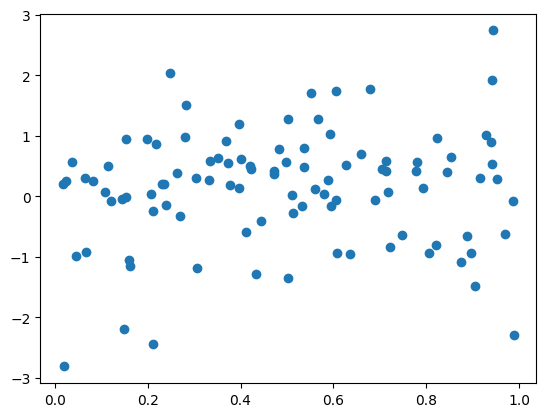

In [ ]:
x = np.random.rand(100)
y = np.random.randn(100)
plt.plot(x,y,'o')

**Ejercicio:** Reproduzca el siguiente gráfico (plt.plot)
hint: xlabel, ylabel, plt.legend

<img src='https://drive.google.com/uc?id=1mbkFW7ZTDAm0E8gH_68OMDcgAIyNzdPj'>


## Scatter

plt.scatter permite controlar el tamaño y color de cada punto por separado (plt.plot no puede).

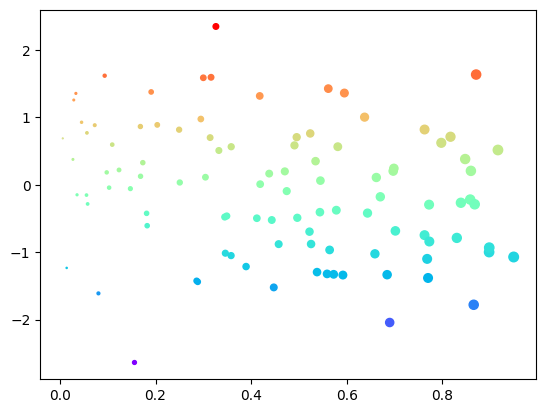

In [ ]:
x = np.random.rand(100)
y = np.random.randn(100)
s = x*50 # tamaño
c = y # color
plt.scatter(x,y,s,c,cmap=plt.cm.rainbow);

## Visulizar mapas de bits

plt.pcolor permite visualizar un arreglo 2D, los valores de cada elemento de mapean a un color y se genera una imagen tipo mapa de bits. Muy util para visualizar matrices!

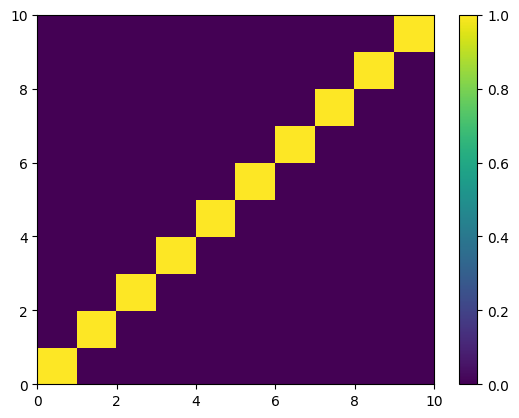

In [ ]:
plt.pcolor(np.eye(10)); #matriz diagonal
plt.colorbar(); # importante siempre incluir una escala con el mapa de colores

## Histogramas

Contar y visualizar ocurrencias de un grupo de elementos.

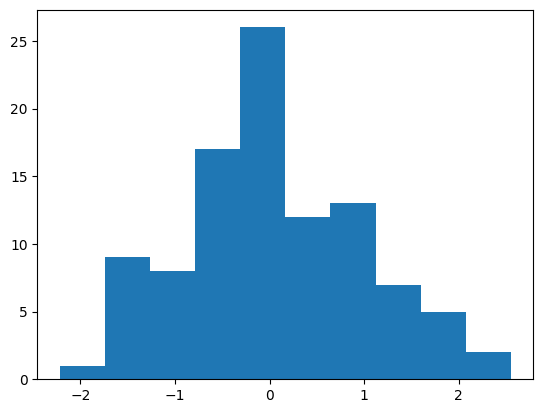

In [ ]:
x = np.random.randn(100)
plt.hist(x);

Se puede controlar el "bineado" utilizando un arreglo determinando el rango y la cantidad de "bines"

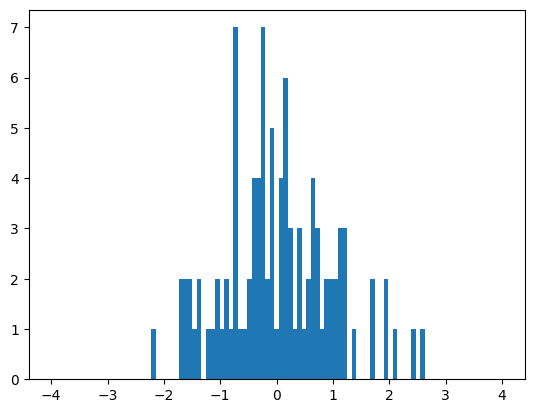

In [ ]:
plt.hist(x,bins=np.linspace(-4,4,100));

### Tiempos de ejecución

Usemos un histograma para visualizar los tiempos que tarda una ejecución. Podemos realizar 5000 medidas del promedio de 10 corridas con timeit

In [ ]:
times = %timeit -q -r 5000 -n 10 -o np.sum(np.random.randn(100))

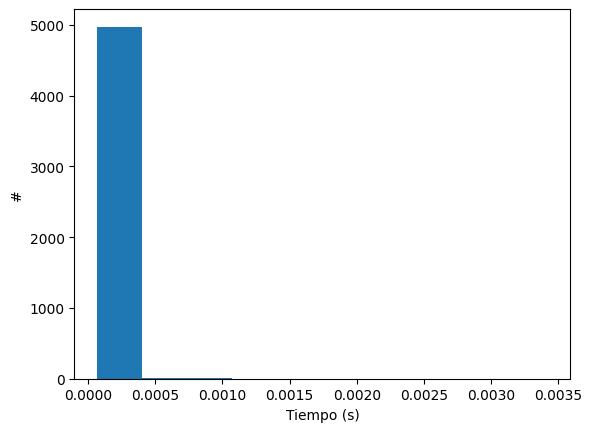

In [ ]:
plt.hist(times.all_runs);
plt.ylabel('#')
plt.xlabel('Tiempo (s)');

Lo mejoramos usando escala logarítmica tanto en los bines como en el conteo (modificar el mínimo bin y el máximo si el gráfico no se ve completo

Mejor 7.263699990289751e-06 segundos


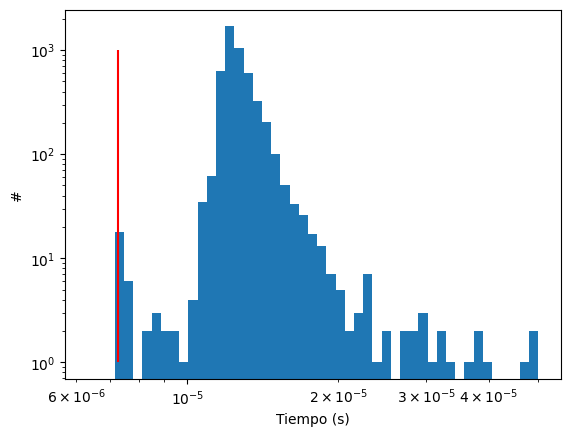

In [ ]:
plt.hist(times.timings,bins=np.logspace(-5.2,-4.3,50));
plt.ylabel('#')
plt.xlabel('Tiempo (s)');
plt.xscale('log')
plt.yscale('log')
plt.vlines(times.best,1,1000, color='r')
print('Mejor', times.best, 'segundos')

**Observación:** La distribución tiene un mínimo, este aproxima el mejor tiempo que puede entregar el sistema para evaluar la rutina. Si la rutina es no determinista o muy larga la forma de la distribución posiblemente cambie y se parezca más a una normal

También se puede utilizar timeit como objeto de Python.

Más info en la documentación https://docs.python.org/3/library/timeit.html

In [ ]:
import timeit
def f(x):
  np.sum(x)

# Obs: Setup se ejecuta una sola vez y no es parte de la medicion
# A diferencia del anterior, acá siempre se mide sobre el mismo X aleatorio
a = np.array(timeit.repeat('f(x)', setup='x=np.random.randn(100)',globals=globals(),number=10, repeat=5000))/10 # ya que el resultado es el acumulado de los 10 loops,

Observación: Tabién se puede usar time(), pero hay que tener cuidado con la precisión.

In [ ]:
import time
start = time.time()
1+100
end = time.time()
end - start

9.107589721679688e-05

In [ ]:
%timeit -r 1 1+100

37 ns ± 0 ns per loop (mean ± std. dev. of 1 run, 10000000 loops each)


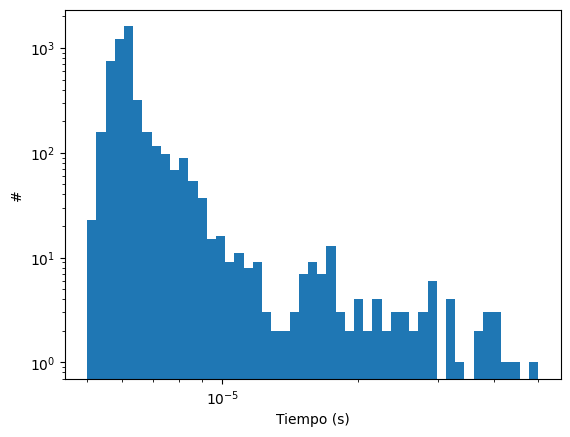

In [ ]:
plt.hist(a,bins=np.logspace(-5.3,-4.3,50));
plt.ylabel('#')
plt.xlabel('Tiempo (s)');
plt.xscale('log')
plt.yscale('log')

Otra opción para visualizar distribuciones son los gráficos de boxplot. Estos representan una distribución a partir de la mediana (50% de los datos, linea naranja), una caja con los cuartiles Q1 (25% de los datos) y Q3 (75% de los datos), y unos "bigotes" con el rango mínimo máximos de los datos. Algunos datos se toman como outliers si superan cierto rango (círculos).

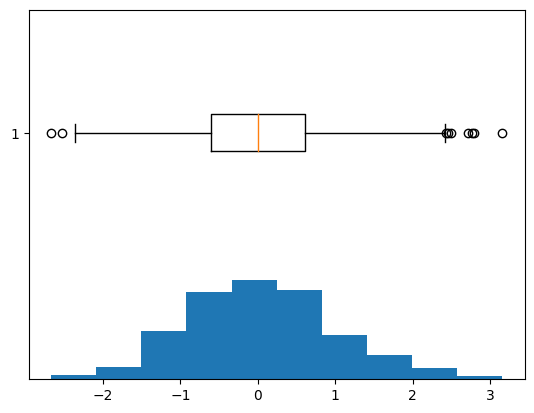

In [ ]:
x = np.random.randn(500)
plt.hist(x, density=True)
plt.boxplot(x,positions=[1],vert=False);